# 04: Model evaluation

The previous notebook trained three classifiers and printed accuracy and AUC for each model. Here this notebook compares them on the held-out test set: confusion matrices, ROC curves overlaid and per-class precision/recall.

Accuracy isn't enough on its own here since ~70% of peptides are negatives for immunogenicity, so a model that always predicts the majority class can score 70% accuracy without necessarily finding real epitopes. AUC is more useful here because it will measure ranking of the models. Precision and recall per class tell us where errors fall: false negatives (a true immunogenic peptide getting called non-immunogenic) and false positives have very different costs depending on downstream use (vaccine design vs. screening).

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score,
)
import joblib
import tensorflow as tf

In [2]:
DATA_DIR  = Path('..') / 'data' / 'processed'
MODEL_DIR = Path('..') / 'outputs' / 'models'
FIG_DIR   = Path('..') / 'outputs'
FIG_DIR.mkdir(parents=True, exist_ok=True)

MAX_LEN, N_AA = 11, 21

## Load test set and trained models

In [3]:
data = np.load(DATA_DIR / 'features.npz')
X_test, y_test = data['X_test'], data['y_test']
X_test_3d = X_test.reshape(-1, MAX_LEN, N_AA)

lr  = joblib.load(MODEL_DIR / 'logistic_regression.joblib')
rf  = joblib.load(MODEL_DIR / 'random_forest.joblib')
cnn = tf.keras.models.load_model(MODEL_DIR / 'cnn_epitope.keras')

print(f'Test set: {X_test.shape[0]:,} peptides  (positive rate {y_test.mean():.3f})')

Test set: 9,521 peptides  (positive rate 0.297)


## Compute predictions once

All metrics derive from two arrays per model: a probability score (used for AUC and ROC) and a 0/1 prediction at threshold 0.5 (used for accuracy, confusion matrix, and per-class metrics). We compute them once and reuse.

In [4]:
preds = {
    'Logistic Regression': {
        'proba': lr.predict_proba(X_test)[:, 1],
    },
    'Random Forest': {
        'proba': rf.predict_proba(X_test)[:, 1],
    },
    'CNN': {
        'proba': cnn.predict(X_test_3d, verbose=0).flatten(),
    },
}
for name, d in preds.items():
    d['pred'] = (d['proba'] >= 0.5).astype(int)

## Headline metrics

Accuracy, ROC-AUC, and average precision (AP) for each model. AP is included because it is more sensitive than ROC-AUC when the positive class is the minority. It focuses on how well positives/immunogenic peptides are ranked near the top

In [11]:
rows = []
for name, d in preds.items():
    rows.append({
        'model':    name,
        'accuracy': accuracy_score(y_test, d['pred']),
        'roc_auc':  roc_auc_score(y_test, d['proba']),
        'avg_prec': average_precision_score(y_test, d['proba']),
    })

summary = pd.DataFrame(rows).set_index('model').round(4)
summary

,accuracy,roc_auc,avg_prec
model,,,
Logistic Regression,0.5959,0.6337,0.4234
Random Forest,0.7531,0.7024,0.5705
CNN,0.5767,0.6489,0.4512


## Confusion matrices

Each cell shows count and in parentheses the row-normalised rate, so the diagonal is recall per class. With class imbalance, raw counts can hide the fact that the minority class is being predicted poorly even when total accuracy looks fine.

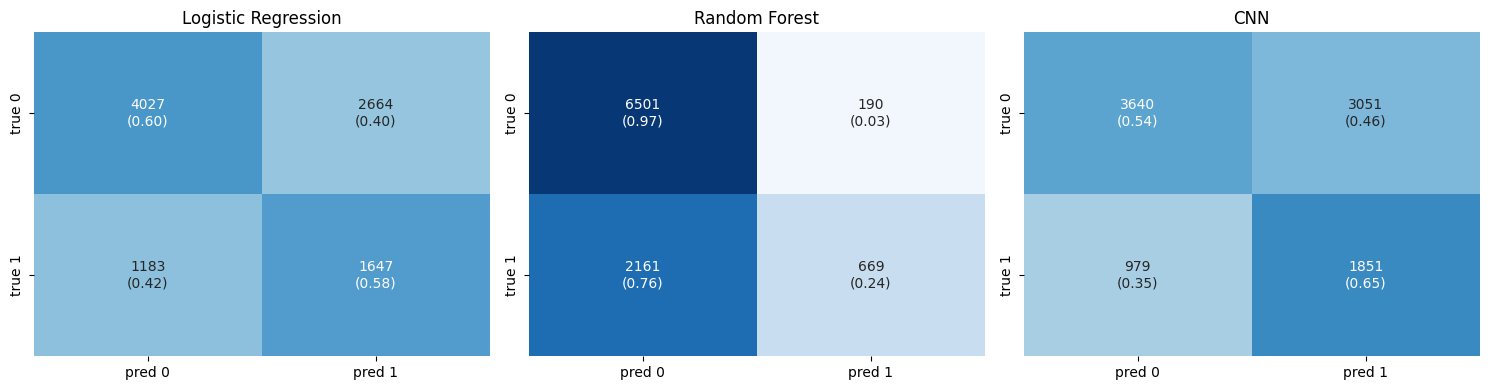

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, d) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, d['pred'])
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    annot = np.array([[f'{c}\n({r:.2f})' for c, r in zip(row_c, row_r)]
                      for row_c, row_r in zip(cm, cm_norm)])
    sns.heatmap(
        cm_norm, annot=annot, fmt='', cmap='Blues',
        xticklabels=['pred 0', 'pred 1'],
        yticklabels=['true 0', 'true 1'],
        cbar=False, vmin=0, vmax=1, ax=ax,
    )
    ax.set_title(name)
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_matrices.png', dpi=150)
plt.show()

## Per-class precision, recall, F1

`classification_report` splits metrics by class. The two rows of interest are class 0 (non-immunogenic) and class 1 (immunogenic). For a screening application where missing real immunogens is costly, recall on class 1 is the most important metric to watch.

In [7]:
for name, d in preds.items():
    print(f'=== {name} ===')
    print(classification_report(y_test, d['pred'],
                                target_names=['non-immunogenic (0)', 'immunogenic (1)'],
                                digits=3))

=== Logistic Regression ===
                     precision    recall  f1-score   support

non-immunogenic (0)      0.773     0.602     0.677      6691
    immunogenic (1)      0.382     0.582     0.461      2830

           accuracy                          0.596      9521
          macro avg      0.577     0.592     0.569      9521
       weighted avg      0.657     0.596     0.613      9521

=== Random Forest ===
                     precision    recall  f1-score   support

non-immunogenic (0)      0.751     0.972     0.847      6691
    immunogenic (1)      0.779     0.236     0.363      2830

           accuracy                          0.753      9521
          macro avg      0.765     0.604     0.605      9521
       weighted avg      0.759     0.753     0.703      9521

=== CNN ===
                     precision    recall  f1-score   support

non-immunogenic (0)      0.788     0.544     0.644      6691
    immunogenic (1)      0.378     0.654     0.479      2830

           accu

## ROC curves overlaid

All three models' ROC curves are presented on the graph. The diagonal is the random-guessing baseline (AUC = 0.5).
Here RF is above LR and CNN and therefore better. They are matching modest AUCs in the range of around 0.63-0.70.

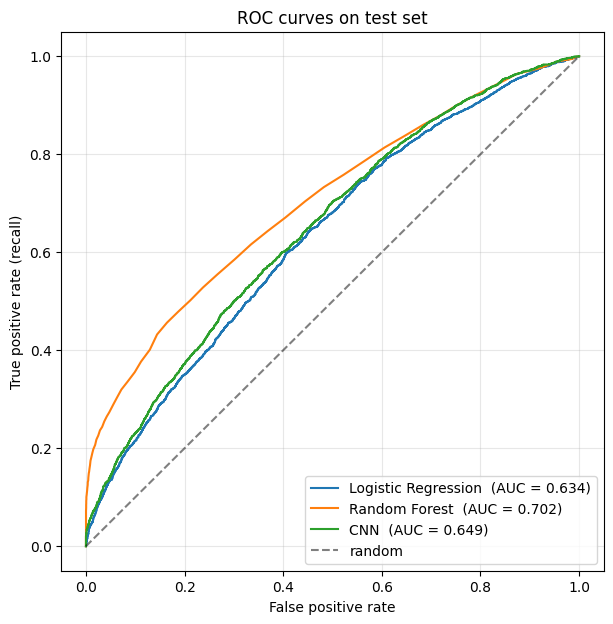

In [8]:
plt.figure(figsize=(7, 7))
for name, d in preds.items():
    fpr, tpr, _ = roc_curve(y_test, d['proba'])
    auc = roc_auc_score(y_test, d['proba'])
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='random')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate (recall)')
plt.title('ROC curves on test set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig(FIG_DIR / 'roc_curves.png', dpi=150)
plt.show()

## Precision-recall curves

Same comparison, but precision against recall instead of ROC. With class imbalance, this view is often more informative than ROC since it directly shows what fraction of our positive predictions are correct (precision) at each recall level. Dashed line = positive rate (~0.30) so the curves above the line do better than that baseline. Here RF sits above it but only by a small amount. 

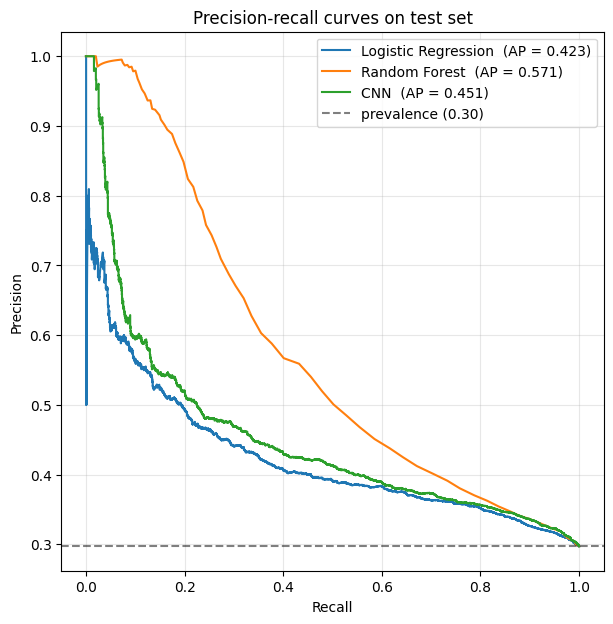

In [9]:
plt.figure(figsize=(7, 7))
for name, d in preds.items():
    p, r, _ = precision_recall_curve(y_test, d['proba'])
    ap = average_precision_score(y_test, d['proba'])
    plt.plot(r, p, label=f'{name}  (AP = {ap:.3f})')
plt.axhline(y_test.mean(), color='k', linestyle='--', alpha=0.5,
            label=f'prevalence ({y_test.mean():.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-recall curves on test set')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.savefig(FIG_DIR / 'pr_curves.png', dpi=150)
plt.show()

## Threshold sweep on the best model

RF had the highest AUC, so many decision thresholds were tested. Default is 0.5, but with class-weighted training that is not always the best cutoff: lower cutoff finds more epitopes but adds false positive and higher would be stricter. 

The plot shows how precision, recall, and F1 change as the threshold goes from 0.05 to 0.95. Lower threshold = call more peptides immunogenic (higher recall, lower precision). Higher threshold = the opposite.

The dotted line marks the threshold with the best F1. For screening, lower threshold is safer to catch more real epitopes, even if it means having some false positives.

Best model by AUC: Random Forest


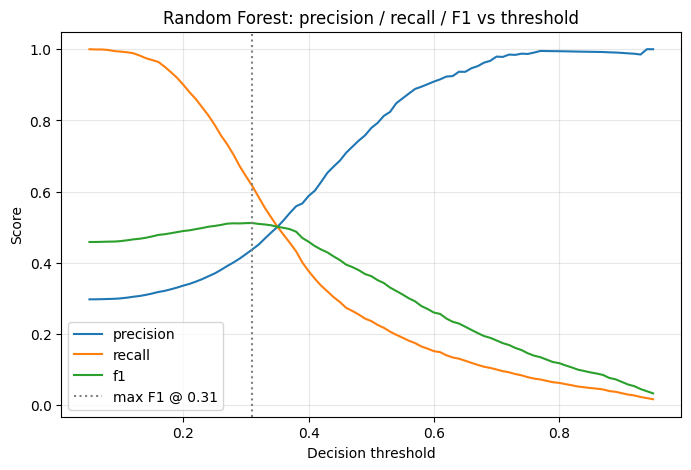

In [12]:
best_name = summary['roc_auc'].idxmax()
best_proba = preds[best_name]['proba']
print(f'Best model by AUC: {best_name}')

thresholds = np.linspace(0.05, 0.95, 91)
rows = []
for t in thresholds:
    pred = (best_proba >= t).astype(int)
    tp = ((pred == 1) & (y_test == 1)).sum()
    fp = ((pred == 1) & (y_test == 0)).sum()
    fn = ((pred == 0) & (y_test == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    rows.append((t, prec, rec, f1))
sweep = pd.DataFrame(rows, columns=['threshold', 'precision', 'recall', 'f1'])

plt.figure(figsize=(8, 5))
for col in ['precision', 'recall', 'f1']:
    plt.plot(sweep['threshold'], sweep[col], label=col)
best_t = sweep.loc[sweep['f1'].idxmax(), 'threshold']
plt.axvline(best_t, color='grey', linestyle=':', label=f'max F1 @ {best_t:.2f}')
plt.xlabel('Decision threshold')
plt.ylabel('Score')
plt.title(f'{best_name}: precision / recall / F1 vs threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(FIG_DIR / 'threshold_sweep.png', dpi=150)
plt.show()

## Reading the results

RF has the best AUC (~0.70) and highest accuracy (~0.75), but notebook 03 showed train accuracy of 1.0, meaning it overfit. Also, RF recall on immunogenic peptides is only ~0.24, so it misses most true epitopes even though accuracy looks good.

LR and CNN are close on AUC (~0.63-0.65). The CNN did not really beat the linear baseline on this one-hot input.

None of the models are amazing, which makes sense : immunogenicity depends on MHC context and T-cell recognition, not just peptide sequence.

One possible improvement from notebook 02 is alignment: right-padding can put the C-terminal anchor (PΩ) in different columns for 8-11mers. Center-padding might help, but that's yet to be tested.

Next notebook will take the trained models and look at which positions and amino acids drive predictions, and whether that matches MHC class I biology and TCR contact positions.